In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('ecommerce_sales.csv')
df['returned']=df['returned'].map({'Yes':1,'No':0})
df = df.drop(['order_id', 'customer_id', 'product_id'], axis=1, errors='ignore')
numerical_col=df.select_dtypes(include=['int64','float64'])
categorical_col=df.select_dtypes(include=['object'])
df_encoded = pd.get_dummies(df, drop_first=True)

In [4]:
target_col='total_amount'
date_col='order_date'
df[date_col]=pd.to_datetime(df[date_col],format='%y-%m-%d')
df=df.set_index(date_col).sort_index()
y=pd.to_numeric(df[target_col],errors='coerce').dropna()

In [5]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from statsmodels.tsa.stattools import adfuller
y = y.resample('D').sum()
p_value=adfuller(y.dropna())[1]
d=1 if p_value>0.05 else 0

print(f"p_value :{p_value}")
print(f"d value:{d}")

p_value :3.459955269501552e-27
d value:0


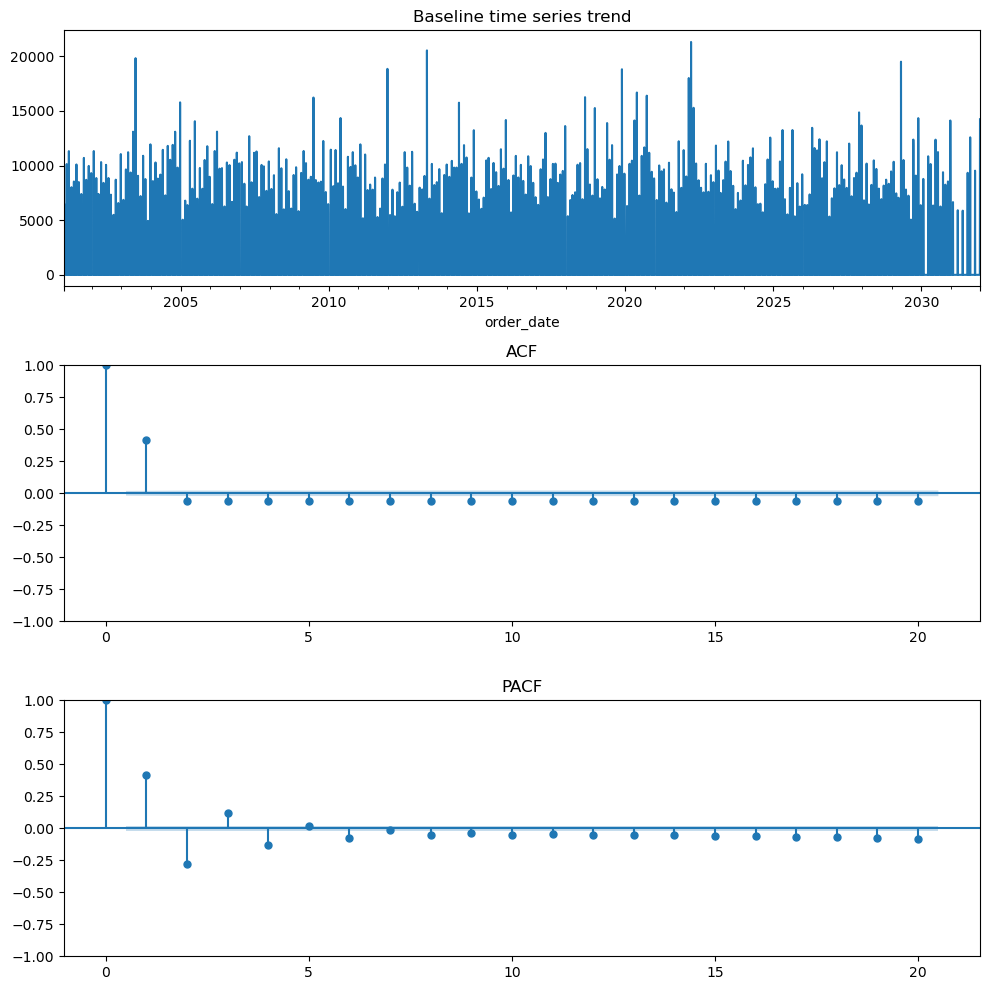

In [6]:
fig,axes =plt.subplots(3,1,figsize=(10,10))
y.plot(ax=axes[0],title='Baseline time series trend')
plot_acf(y,ax=axes[1],lags=20,title='ACF')
plot_pacf(y,ax=axes[2],lags=20,title='PACF')
plt.tight_layout()
plt.show()

                               SARIMAX Results                                
Dep. Variable:           total_amount   No. Observations:                11292
Model:                 ARIMA(2, 0, 2)   Log Likelihood             -100397.109
Date:                Wed, 29 Jul 2026   AIC                         200806.218
Time:                        15:19:39   BIC                         200850.209
Sample:                    01-24-2001   HQIC                        200821.019
                         - 12-24-2031                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        519.4202     14.575     35.637      0.000     490.853     547.987
ar.L1          0.9160      0.016     58.825      0.000       0.885       0.946
ar.L2         -0.0667      0.019     -3.572      0.0

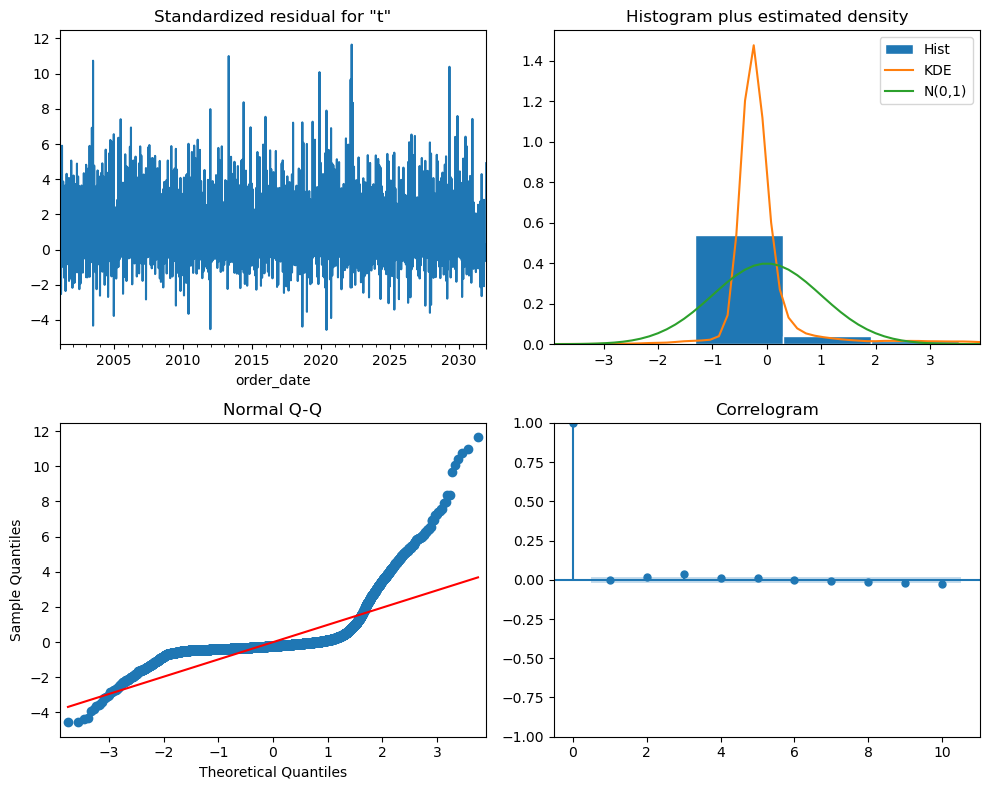

In [7]:
p,q=2,2
model=ARIMA(y,order=(p,d,q))
model_fit=model.fit()
print(model_fit.summary())

model_fit.plot_diagnostics(figsize=(10,8))
plt.tight_layout()
plt.show()

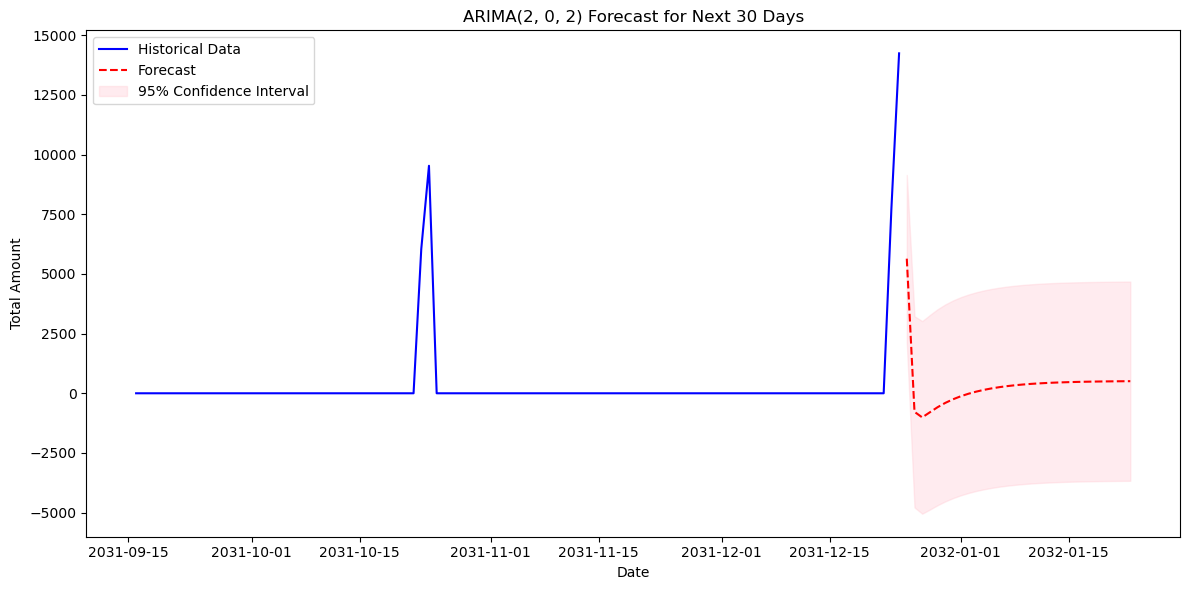

Forecasted Values for the next 5 days:
2031-12-25    5640.402607
2031-12-26    -777.915072
2031-12-27   -1010.501850
2031-12-28    -795.367992
2031-12-29    -582.799688
Freq: D, Name: predicted_mean, dtype: float64


In [9]:
forecast_steps = 30
forecast_results = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(y.index[-100:], y.iloc[-100:], label='Historical Data', color='blue')
plt.plot(forecast_mean.index, forecast_mean, label='Forecast', color='red', linestyle='--')

plt.fill_between(conf_int.index, 
                 conf_int.iloc[:, 0], 
                 conf_int.iloc[:, 1], 
                 color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'ARIMA(2, 0, 2) Forecast for Next {forecast_steps} Days')
plt.xlabel('Date')
plt.ylabel('Total Amount')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

print("Forecasted Values for the next 5 days:")
print(forecast_mean.head())